In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
sns.set(style="whitegrid")

In [12]:
# Veriyi yükle
df = pd.read_csv('Social_Network_Ads.csv')

# 1. Veriye genel bakış
print("--- Veri Setinin İlk 5 Satırı ---")
display(df.head())

# 2. Eksik veri (NaN) kontrolü
print("\n--- Eksik Veri Kontrolü ---")
print(df.isnull().sum())

# 3. Veri tipleri ve doluluk oranı
print("\n--- Veri Bilgisi ---")
df.info()

# 4. İstatistiksel özet
print("\n--- İstatistiksel Özet ---")
display(df.describe())

--- Veri Setinin İlk 5 Satırı ---


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



--- Eksik Veri Kontrolü ---
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

--- İstatistiksel Özet ---


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


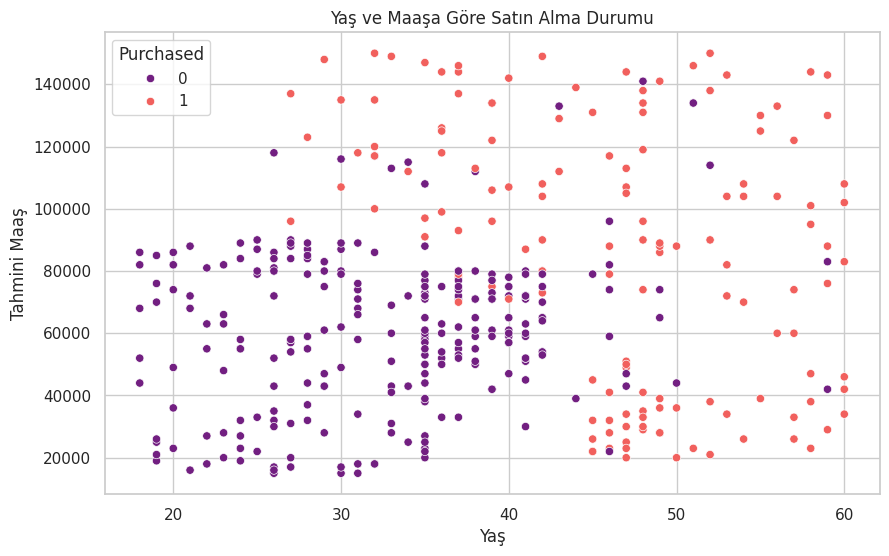

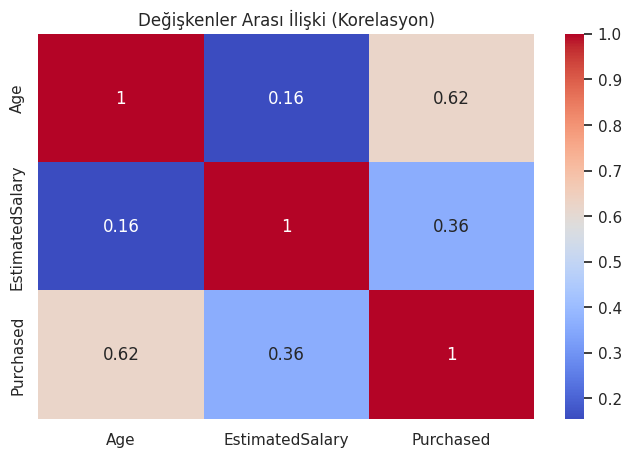

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', palette='magma')
plt.title('Yaş ve Maaşa Göre Satın Alma Durumu')
plt.xlabel('Yaş')
plt.ylabel('Tahmini Maaş')
plt.show()

# Korelasyon matrisi: Hangi değişken hedefle daha ilişkili?
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Age', 'EstimatedSalary', 'Purchased']].corr(), annot=True, cmap='coolwarm')
plt.title('Değişkenler Arası İlişki (Korelasyon)')
plt.show()

In [14]:
# Gereksiz sütunları (User ID, Gender) kullanmıyoruz.
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Veriyi %25 test, %75 eğitim olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standartlaştırma (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



--- LOJİSTİK REGRESYON RAPORU ---
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100


--- LİNEER REGRESYON RAPORU ---
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100



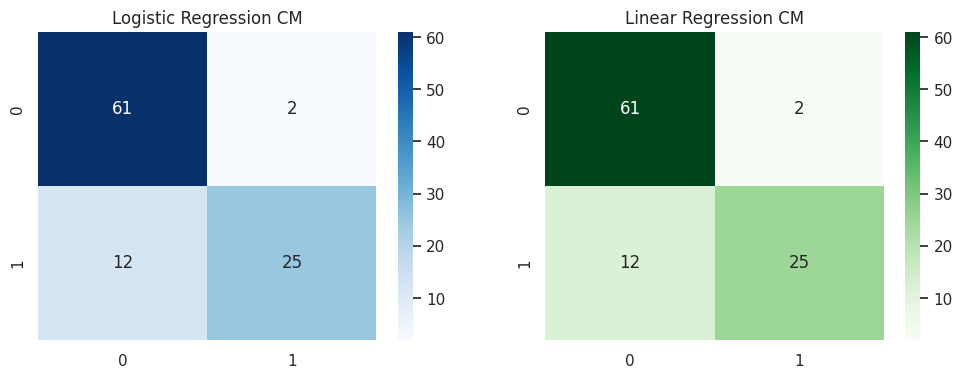

In [15]:
# 1. Lojistik Regresyon
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# 2. Lineer Regresyon
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin_raw = lin_reg.predict(X_test_scaled)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int) # 0.5 eşiği ile sınıfa dönüştür

# Performans Raporları
print("--- LOJİSTİK REGRESYON RAPORU ---")
print(classification_report(y_test, y_pred_log))

print("\n--- LİNEER REGRESYON RAPORU ---")
print(classification_report(y_test, y_pred_lin))

# Confusion Matrix Görselleştirme
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Logistic Regression CM')
sns.heatmap(confusion_matrix(y_test, y_pred_lin), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('Linear Regression CM')
plt.show()

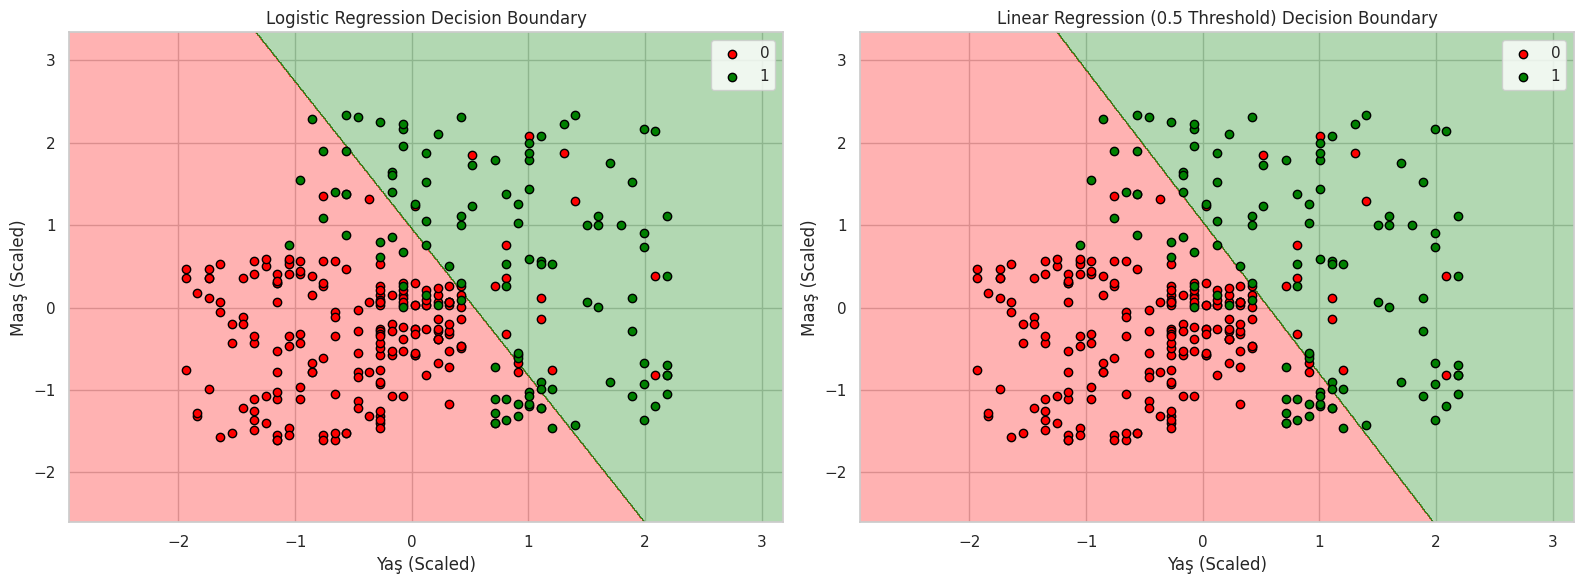

In [16]:

from matplotlib.colors import ListedColormap

def plot_decision_boundary(X_set, y_set, model, title, ax):
    X1, X2 = np.meshgrid(np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
                         np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01))

    # Grid üzerindeki her nokta için modelin tahminini alıyoruz
    if isinstance(model, LinearRegression):
        Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
        Z = (Z >= 0.5).astype(int) # Linear model için 0.5 eşiği
    else:
        Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)


    ax.contourf(X1, X2, Z.reshape(X1.shape), alpha=0.3, cmap=ListedColormap(('red', 'green')))

    # Gerçek veri noktalarını saçılım grafiği olarak ekleme
    for i, j in enumerate(np.unique(y_set)):
        ax.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                   c=[ListedColormap(('red', 'green'))(i)], label=j, edgecolors='black')

    ax.set_title(title)
    ax.set_xlabel('Yaş (Scaled)')
    ax.set_ylabel('Maaş (Scaled)')
    ax.legend()

# İki modeli yan yana çizdirme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(X_train_scaled, y_train, log_reg, 'Logistic Regression Decision Boundary', ax1)
plot_decision_boundary(X_train_scaled, y_train, lin_reg, 'Linear Regression (0.5 Threshold) Decision Boundary', ax2)

plt.tight_layout()
plt.show()